# Data Visualization and Analysis

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## --- 1. Load the Data --- ##

# Make sure 'pulsar_stars.csv' is in the same folder as your script
file_path = 'pulsar_stars.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please make sure the dataset is in the same directory as your script.")
    exit()

## --- 2. Basic Data Exploration --- ##
print("--- Dataset Information ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())
print("\n--- Statistical Summary ---")
print(df.describe())
print("-" * 27)




--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                17898 non-null  float64
 1    Standard deviation of the integrated profile  17898 non-null  float64
 2    Excess kurtosis of the integrated profile     17898 non-null  float64
 3    Skewness of the integrated profile            17898 non-null  float64
 4    Mean of the DM-SNR curve                      17898 non-null  float64
 5    Standard deviation of the DM-SNR curve        17898 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7    Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                   17898 non-null  int64  
dtypes: float64(8), int64(1)

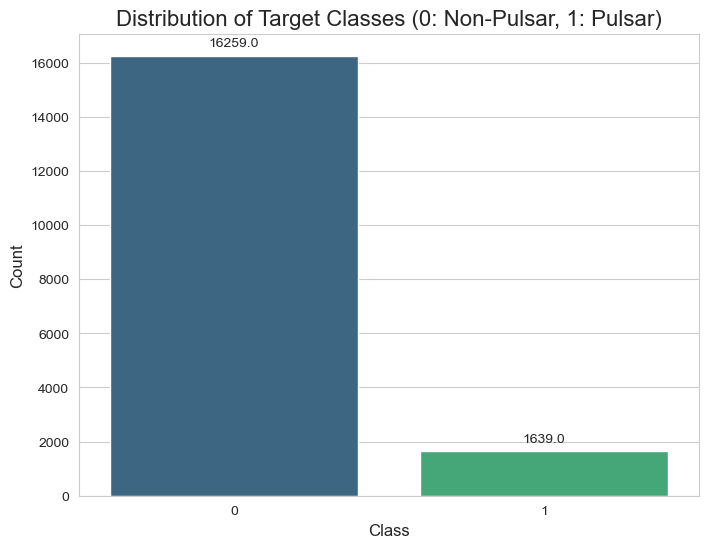

In [3]:
## --- 3. Create Visualizations --- ##

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# --- Plot 1: Target Class Distribution ---
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='target_class', data=df, palette='viridis')
plt.title('Distribution of Target Classes (0: Non-Pulsar, 1: Pulsar)', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()





Displaying feature distributions...


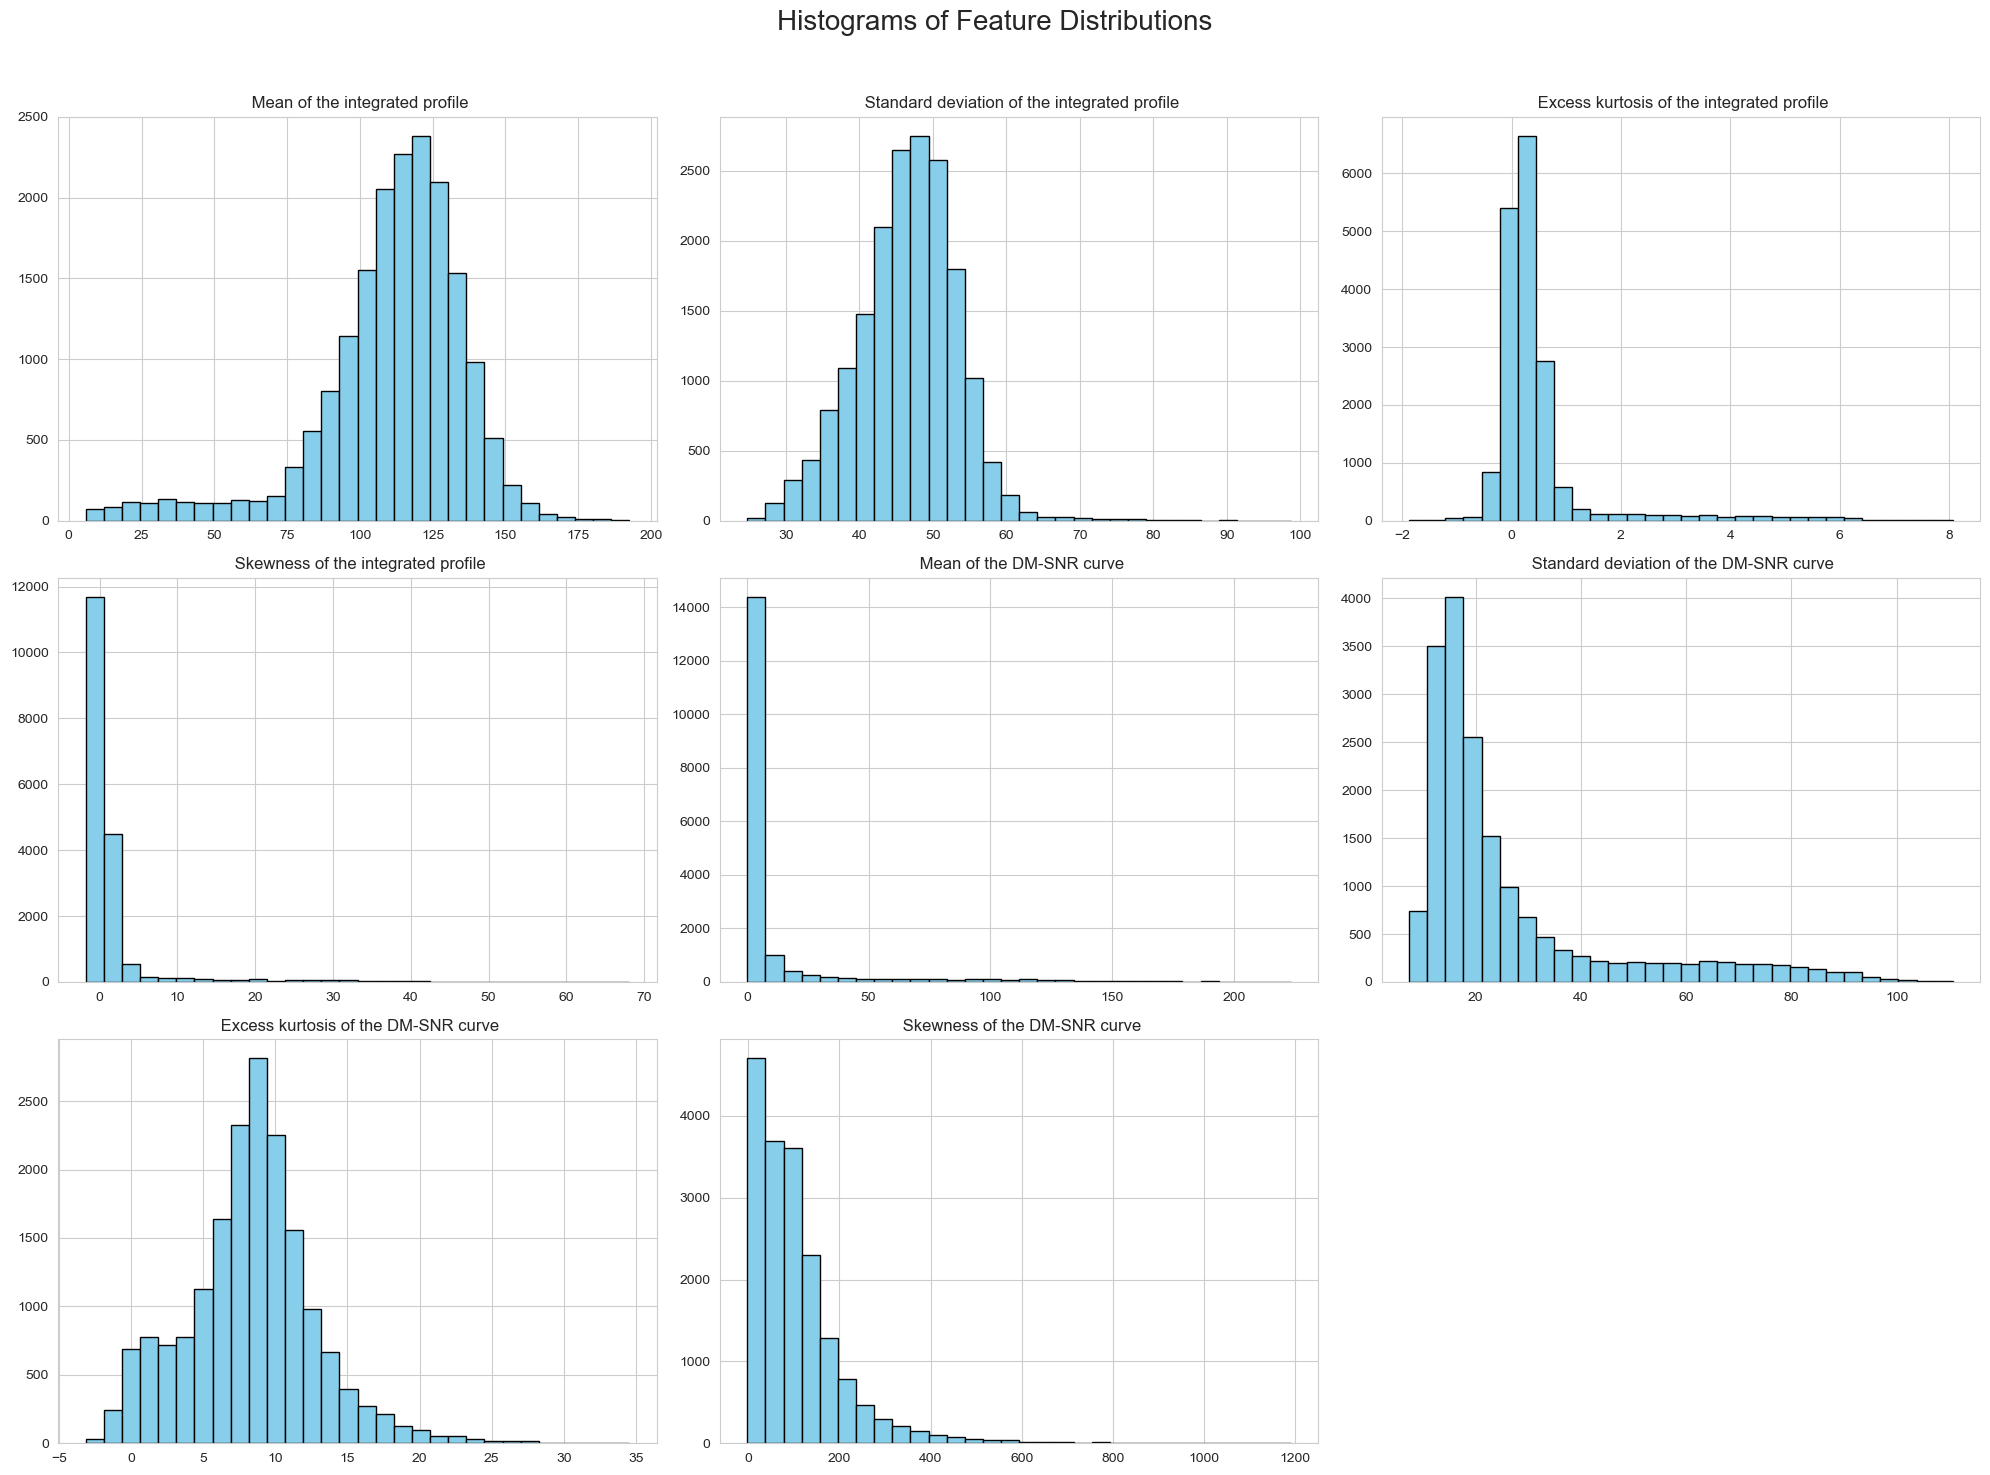

In [4]:
## --- Plot 2: Histograms of Each Feature --- ##
# This helps to understand the distribution of values for each feature
print("\nDisplaying feature distributions...")
df.drop('target_class', axis=1).hist(bins=30, figsize=(20, 15), layout=(3, 3), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Feature Distributions', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
plt.show()




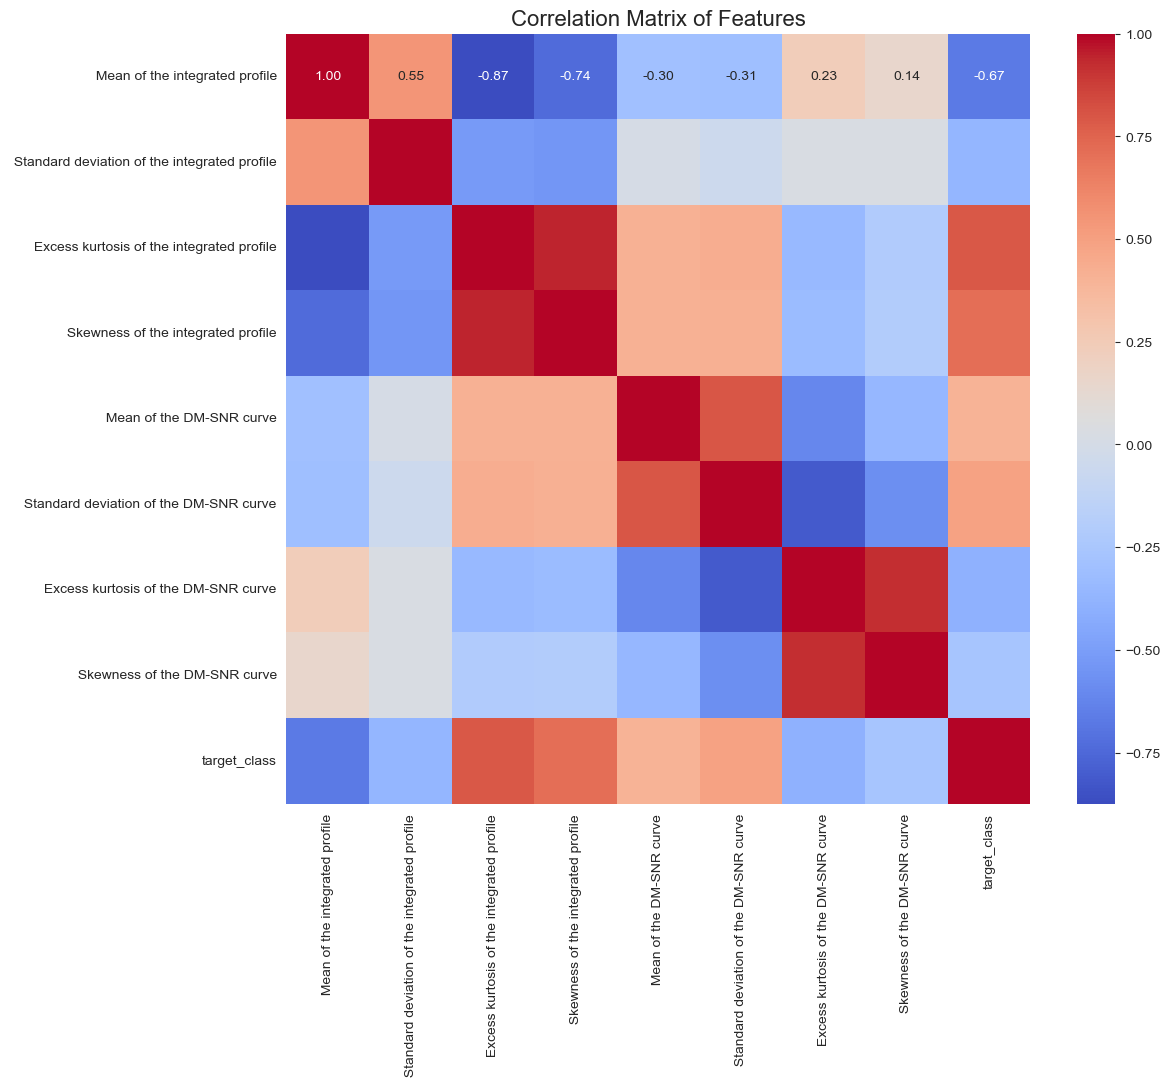

In [5]:
## --- Plot 3: Correlation Heatmap --- ##
# This shows how strongly features are linearly related to each other
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()





Generating pair plot (this might take a moment)...


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a le

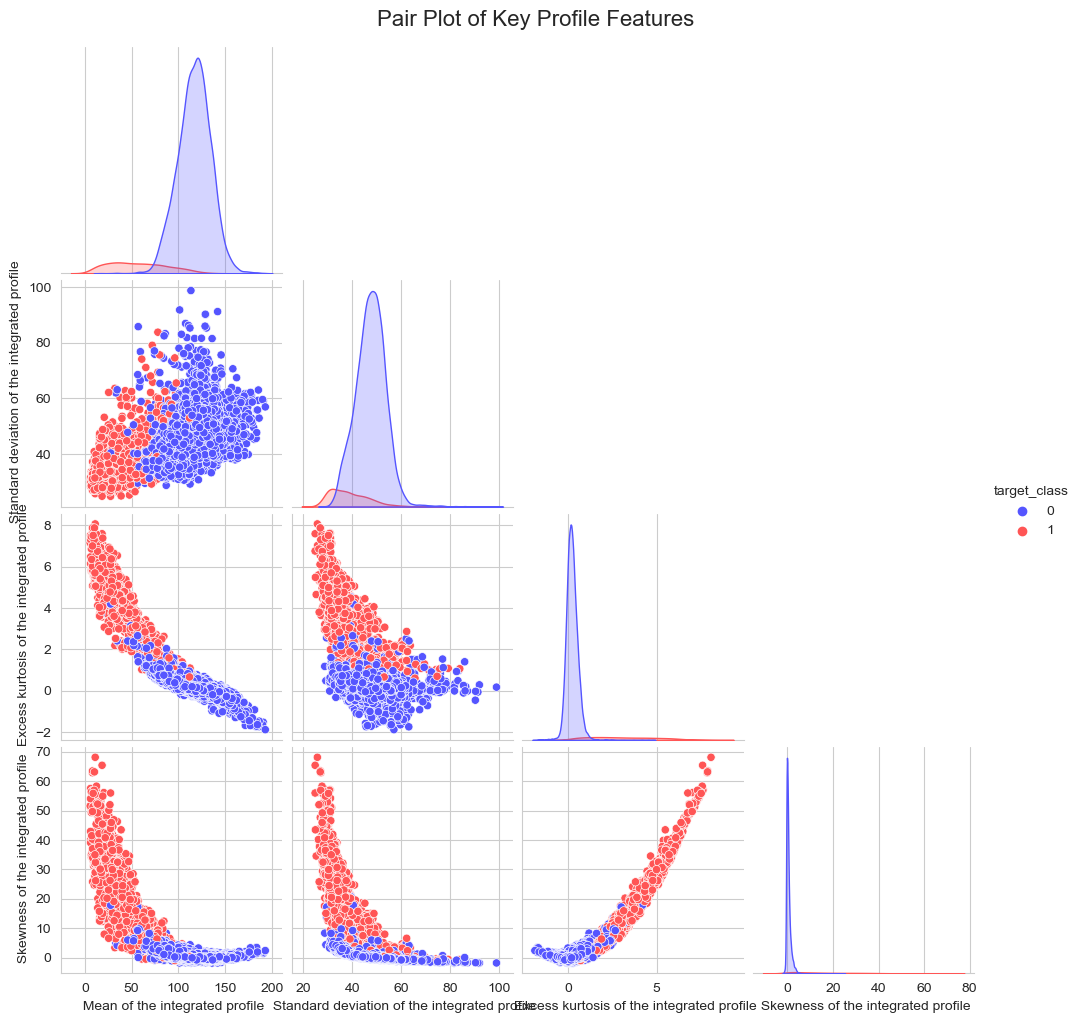

In [6]:
## --- Plot 4: Pair Plot of Key Features --- ##
## A pair plot can be slow with many features. Let's select a few interesting ones. ##
## We'll pick the 'mean', 'std', and 'kurtosis' of the integrated profile. ##
print("\nGenerating pair plot (this might take a moment)...")
key_features = [
    ' Mean of the integrated profile',
    ' Standard deviation of the integrated profile',
    ' Excess kurtosis of the integrated profile',
    ' Skewness of the integrated profile',
    'target_class'
]
sns.pairplot(df[key_features], hue='target_class', palette='seismic', corner=True)
plt.suptitle('Pair Plot of Key Profile Features', y=1.02, fontsize=16)
plt.show()

# Classical Models

In [7]:
import pandas as pd
import numpy as np
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 1. Load and Prepare the Pulsar Dataset ---

# Load the dataset from the CSV file
try:
    pulsar_df = pd.read_csv('pulsar_stars.csv')
except FileNotFoundError:
    print("Error: 'pulsar_stars.csv' not found.")
    print("Please download the dataset and place it in the same directory as this script.")
    exit()

# Create a balanced subset for more effective training
pulsars = pulsar_df[pulsar_df['target_class'] == 1]
non_pulsars = pulsar_df[pulsar_df['target_class'] == 0].sample(n=len(pulsars), random_state=69)
df_balanced = pd.concat([pulsars, non_pulsars])

X = df_balanced.drop('target_class', axis=1).values
Y = df_balanced['target_class'].values

# Scale the features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split the data
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, test_size=0.3, random_state=69)


# --- 2. Train and Evaluate Classical Models ---
print("--- Training and Evaluating Classical Models ---")

# Support Vector Machine (SVM)
svm_model = SVC()
svm_model.fit(X_train, Y_train)
svm_predictions = svm_model.predict(X_test)
svm_accuracy = accuracy_score(Y_test, svm_predictions)


# Random Forest
rf_model = RandomForestClassifier(random_state=69)
rf_model.fit(X_train, Y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(Y_test, rf_predictions)


# --- 3. Final Results Summary ---
print("\n--- Model Comparison Summary ---")
print(f"SVM Test Accuracy:           {svm_accuracy:.3f}")
print(f"Random Forest Test Accuracy: {rf_accuracy:.3f}")
print("--------------------------------")

--- Training and Evaluating Classical Models ---

--- Model Comparison Summary ---
SVM Test Accuracy:           0.944
Random Forest Test Accuracy: 0.947
--------------------------------


# Variational Quantum Classifier

In [1]:
import pandas as pd
import numpy as np
from sklearn import model_selection
from qiskit_aer import Aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import copy

# --- 1. Load and Prepare the Pulsar Dataset ---

# Load the dataset from the CSV file
try:
    pulsar_df = pd.read_csv('pulsar_stars.csv')
except FileNotFoundError:
    print("Error: 'pulsar_stars.csv' not found.")
    print("Please download the dataset and place it in the same directory as this script.")
    # Exit or handle the error appropriately
    exit()


# Create a balanced subset for more effective training
pulsars = pulsar_df[pulsar_df['target_class'] == 1]
non_pulsars = pulsar_df[pulsar_df['target_class'] == 0].sample(n=len(pulsars), random_state=69)
df_balanced = pd.concat([pulsars, non_pulsars])

X = df_balanced.drop('target_class', axis=1).values
Y = df_balanced['target_class'].values

# It's good practice to scale the features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split the data
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, test_size=0.3, random_state=69)

# --- 2. Define Quantum Components ---

# Number of features/qubits (CHANGED TO 8 FOR PULSAR DATA)
N = 8

def feature_map(X):
    """Creates the feature map quantum circuit."""
    q = QuantumRegister(N)
    c = ClassicalRegister(1)
    qc = QuantumCircuit(q, c)

    # Use a common feature map structure like ZZFeatureMap
    for i in range(N):
        qc.h(i)
        qc.rz(2 * X[i], i)
    for i in range(N-1):
        qc.cx(i, i+1)
        qc.rz(2 * (np.pi - X[i]) * (np.pi - X[i+1]), i+1)
        qc.cx(i, i+1)
    return qc, c

def variational_circuit(qc, theta):
    """Creates the variational circuit."""
    for i in range(N):
        qc.ry(theta[i], i)
    return qc

# --- 3. Define the Quantum Neural Network and Training Functions ---

def quantum_nn(X, theta):
    """Executes the full quantum circuit."""
    qc, c = feature_map(X)
    qc = variational_circuit(qc, theta)
    qc.measure(0, c)

    shots = int(1E4)
    backend = Aer.get_backend("qasm_simulator")
    job = backend.run(qc, shots=shots)
    result = job.result()
    
    counts = result.get_counts(qc)
    return counts.get("1", 0) / shots

def loss(prediction, target):
    """Simple squared error loss function."""
    return (target - prediction)**2

def gradient(X, Y, theta):
    """Computes the gradient of the loss function."""
    delta = 0.01
    grad = []
    
    for i in range(len(theta)):
        dtheta = copy.copy(theta)
        dtheta[i] += delta
        
        pred1 = quantum_nn(X, dtheta)
        pred2 = quantum_nn(X, theta)
        
        grad.append((loss(pred1, Y) - loss(pred2, Y)) / delta)
    return np.array(grad)

def accuracy(X, Y, theta):
    """Calculates the model's accuracy."""
    counter = 0
    for X_i, Y_i in zip(X, Y):
        prediction = quantum_nn(X_i, theta)
        if prediction < 0.5 and Y_i == 0:
            counter += 1
        elif prediction >= 0.5 and Y_i == 1:
            counter += 1
    return counter / len(Y)

# --- 4. Training Loop ---
eta = 0.05
epochs = 20
loss_list = []
theta = np.ones(N)

print("Starting training with Pulsar dataset...")
print("Epoch \t Loss \t Training Accuracy")

for i in range(epochs):
    loss_tmp = []
    for X_i, Y_i in zip(X_train, Y_train):
        prediction = quantum_nn(X_i, theta)
        loss_tmp.append(loss(prediction, Y_i))
        
        # Update parameters using gradient descent
        theta = theta - eta * gradient(X_i, Y_i, theta)
        
    loss_list.append(np.mean(loss_tmp))
    
    acc = accuracy(X_train, Y_train, theta)
    print(f"{i} \t {loss_list[-1]:.3f} \t {acc:.3f}")

print("\nTraining finished!")
# Evaluate on the test set
test_acc = accuracy(X_test, Y_test, theta)
print(f"\nFinal Test Accuracy: {test_acc:.3f}")

Starting training with Pulsar dataset...
Epoch 	 Loss 	 Training Accuracy
0 	 0.261 	 0.566
1 	 0.255 	 0.433
2 	 0.256 	 0.434
3 	 0.261 	 0.563
4 	 0.256 	 0.444
5 	 0.258 	 0.562
6 	 0.251 	 0.438
7 	 0.257 	 0.442
8 	 0.252 	 0.468
9 	 0.253 	 0.496
10 	 0.255 	 0.548
11 	 0.259 	 0.440
12 	 0.267 	 0.434
13 	 0.255 	 0.458
14 	 0.256 	 0.511
15 	 0.252 	 0.550
16 	 0.259 	 0.432
17 	 0.259 	 0.500
18 	 0.252 	 0.436
19 	 0.260 	 0.435

Training finished!

Final Test Accuracy: 0.472
